In [23]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
df = pd.read_csv("D:/Semester 6/Intelligent Programming/project 1/cleaned_data.csv")

df = df.replace({True:1, False:0})

print("Data Loaded Successfully")

Data Loaded Successfully


C:\Users\dell\AppData\Local\Temp\ipykernel_20184\1846386317.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace({True:1, False:0})


In [25]:
# Statistical Summary
print("Statistical Summary:")
display(df.describe())

Statistical Summary:


,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,ca,target,cp_1,cp_2,cp_3,restecg_1,restecg_2,slope_1,slope_2,thal_1,thal_2,thal_3
count,305.000000,305.000000,305.000000,305.000000,305.000000,305.000000,305.000000,305.000000,305.000000,305.000000,305.000000,305.000000,305.000000,305.000000,305.000000,305.000000,305.000000,305.000000,305.000000,305.000000
mean,0.530328,0.685246,0.490466,0.491323,0.150820,0.548106,0.327869,0.257869,0.721311,0.540984,0.163934,0.281967,0.078689,0.501639,0.013115,0.468852,0.462295,0.062295,0.547541,0.383607
std,0.187765,0.465181,0.217570,0.194946,0.358461,0.195171,0.470208,0.277181,1.005432,0.499136,0.370824,0.450697,0.269694,0.500819,0.113953,0.499849,0.499396,0.242088,0.498553,0.487063
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.395833,0.000000,0.342105,0.350515,0.000000,0.413793,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.562500,1.000000,0.473684,0.470103,0.000000,0.568966,0.000000,0.200000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
75%,0.666667,1.000000,0.605263,0.610309,0.000000,0.689655,1.000000,0.400000,1.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,4.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


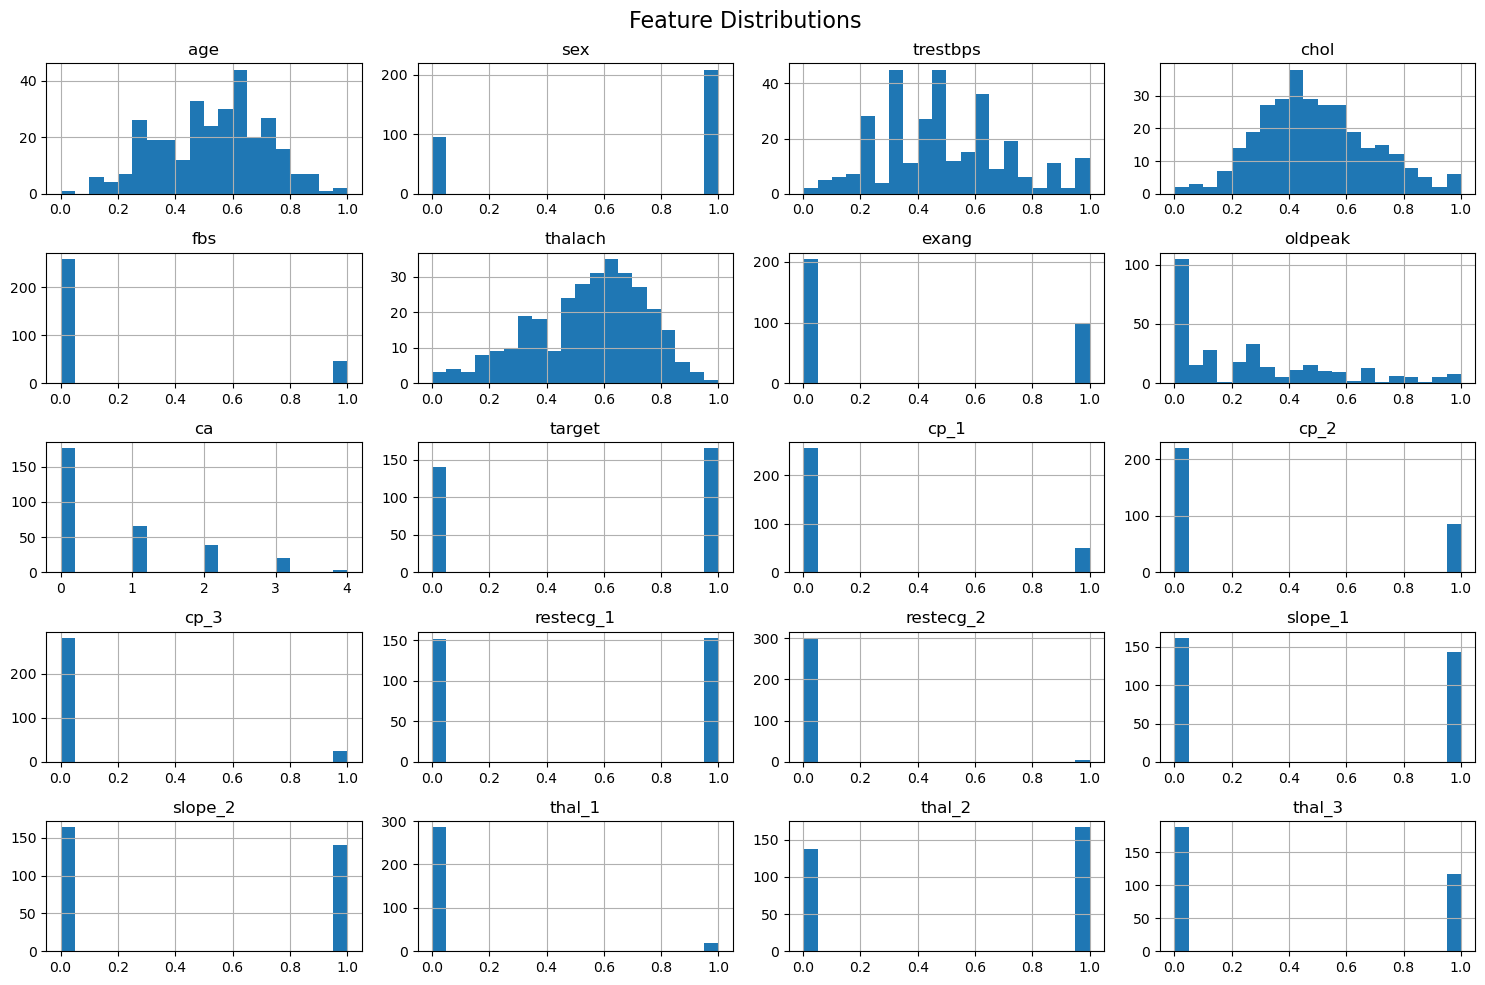

In [26]:
# Distribution of Features
df.hist(figsize=(15,10), bins=20)
plt.suptitle("Feature Distributions", fontsize=16)
plt.tight_layout()
plt.show()

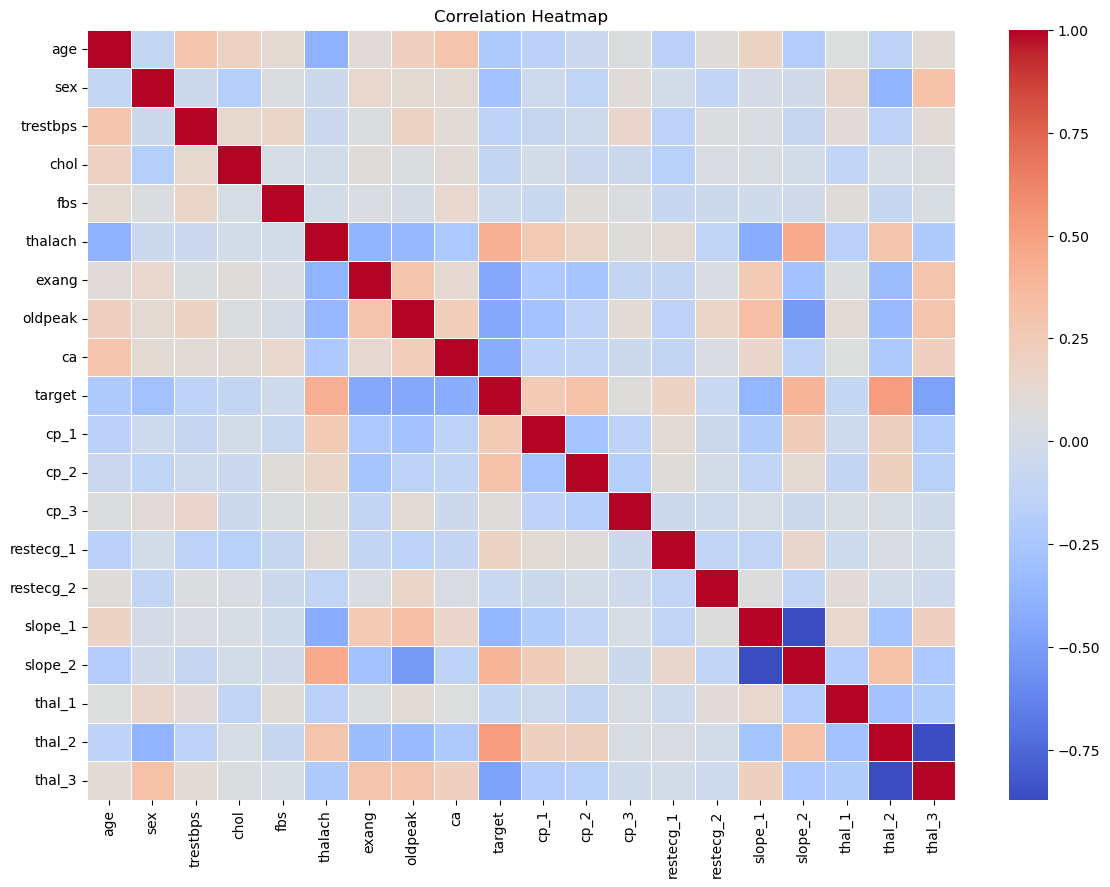

In [27]:
# Correlation Heatmap
plt.figure(figsize=(14,10))

corr = df.corr()

sns.heatmap(corr, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

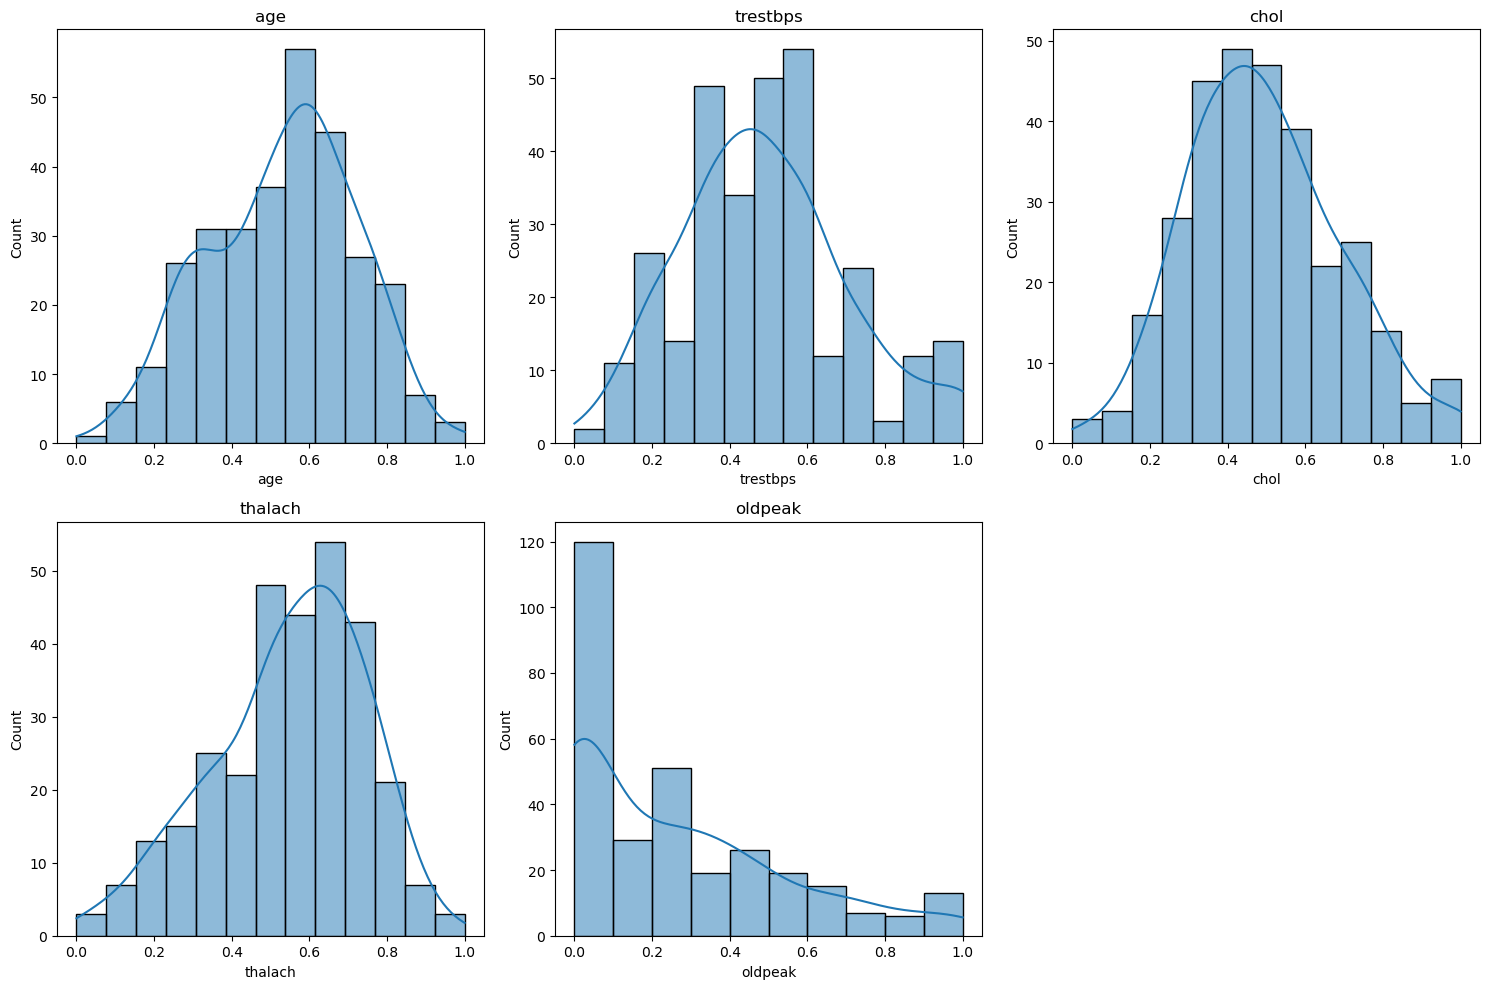

In [28]:
# Histogram
features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

plt.figure(figsize=(15,10))

for i, col in enumerate(features, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df[col], kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

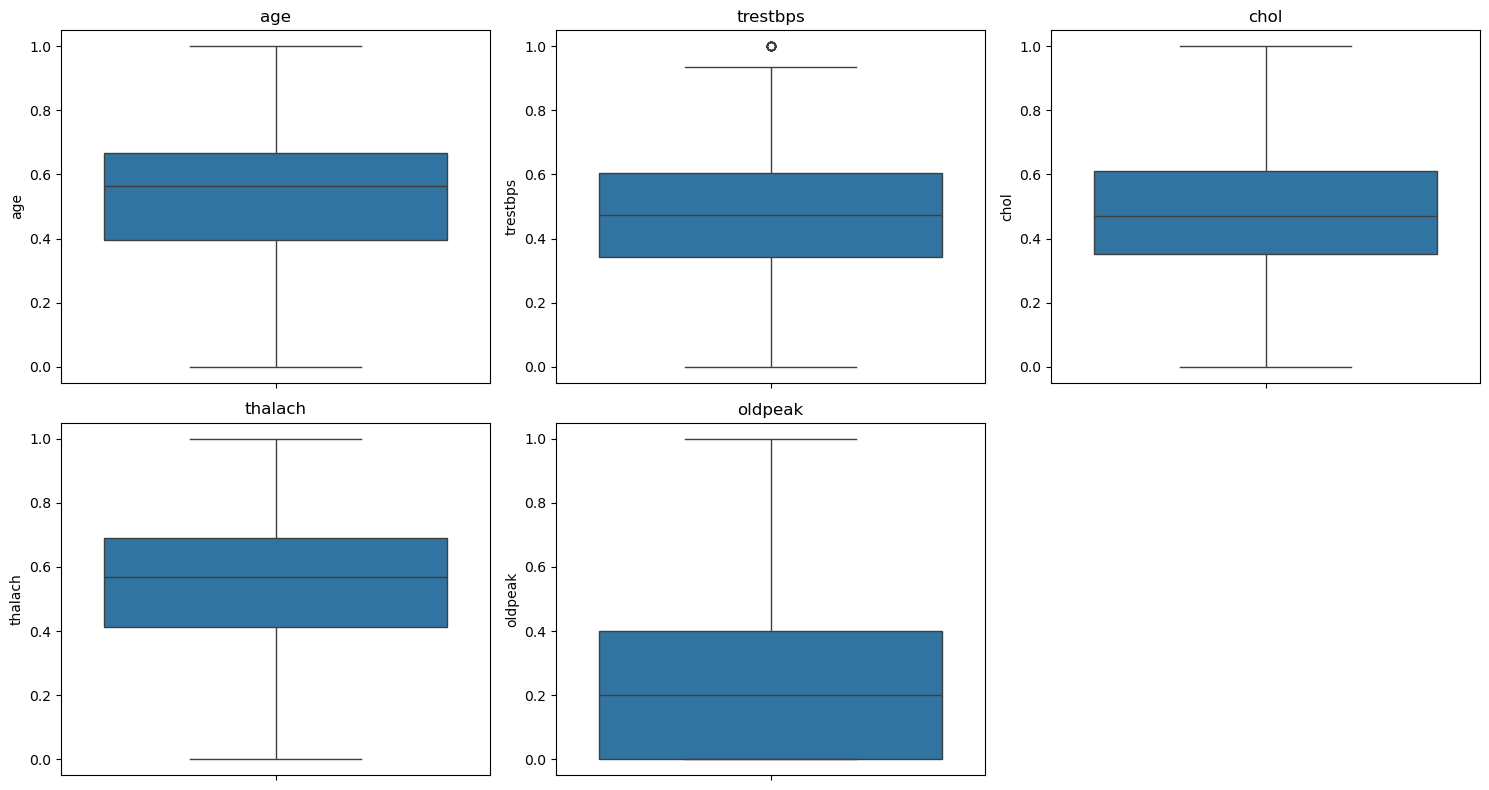

In [29]:
# Boxplots
features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

plt.figure(figsize=(15,8))

for i, col in enumerate(features, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

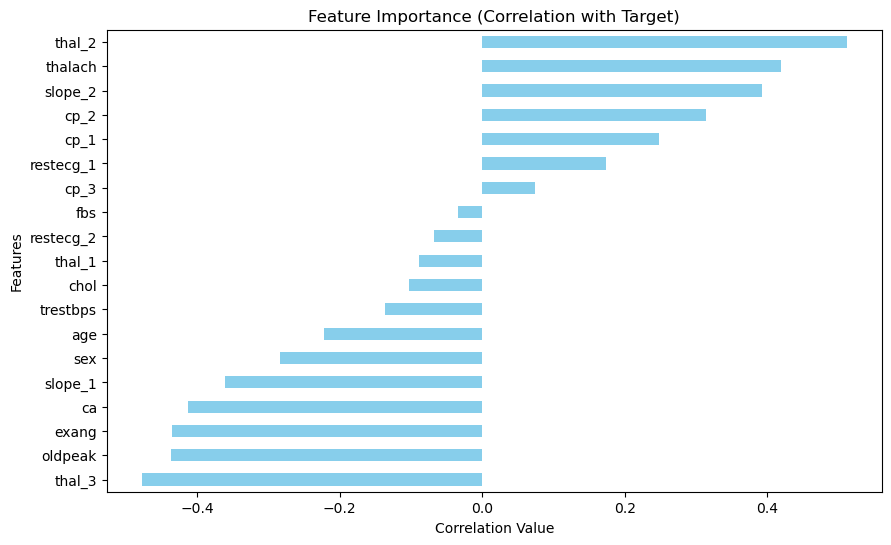

In [30]:
# Feature Importance Correlation based
corr_target = df.corr()['target'].drop('target').sort_values()

plt.figure(figsize=(10,6))
corr_target.plot(kind='barh', color='skyblue')
plt.title("Feature Importance (Correlation with Target)")
plt.xlabel("Correlation Value")
plt.ylabel("Features")
plt.show()

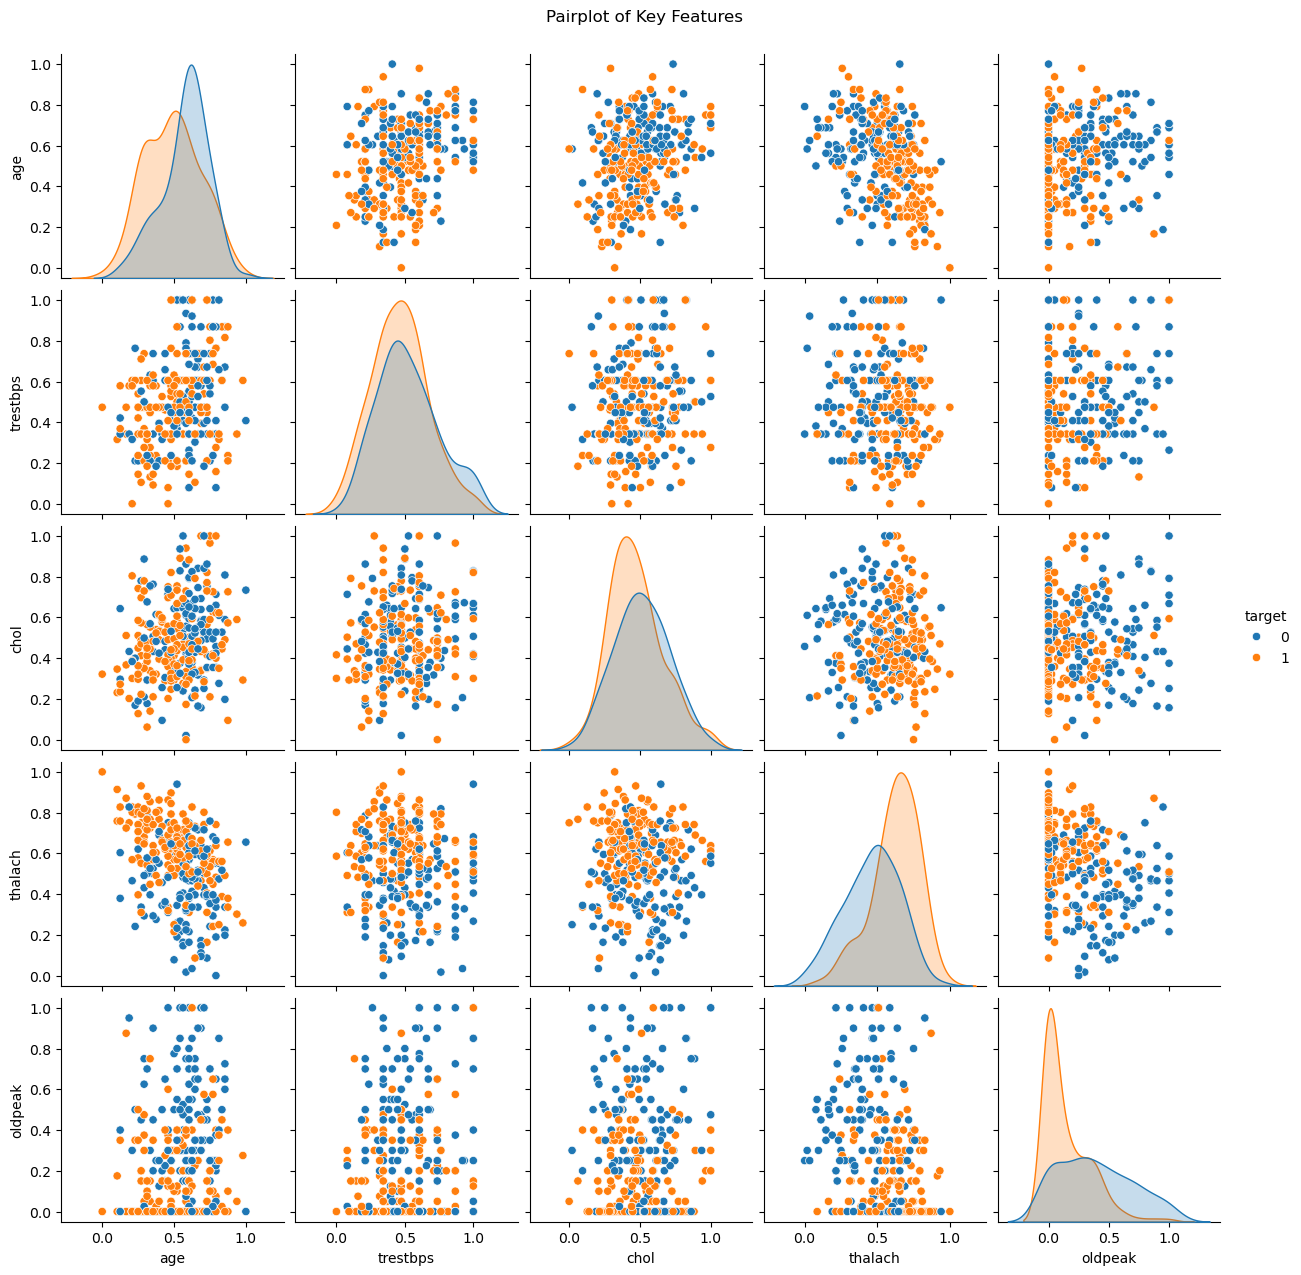

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'target']

sns.pairplot(df[cols], hue='target', diag_kind='kde')
plt.suptitle("Pairplot of Key Features", y=1.02)
plt.show()

In [34]:
import plotly.figure_factory as ff

corr = df.corr()

fig = ff.create_annotated_heatmap(
    z=corr.values,
    x=list(corr.columns),
    y=list(corr.index),
    colorscale='Viridis'
)

fig.update_layout(title="Interactive Correlation Heatmap")
fig.show()

In [35]:
import plotly.express as px

fig = px.scatter(
    df,
    x="age",
    y="chol",
    color="target",
    title="Age vs Cholesterol (Interactive)"
)

fig.show()